# KI Vorlesung – Einstieg: Lineare Regression

Dieses Notebook zeigt ein einfaches Beispiel für Gradient Descent.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Datengenerierung

In [ ]:
x = np.array([1.0, 2.0])
y = np.array([300.0, 500.0])

m = x.shape[0]

# Alternativ: m = len(x)


print(f"x: { x }, y: { y }, m={ m }")

x: [1.e+00 2.e+06], y: [3.e+02 5.e+07], m=2


## Die Daten Plotten

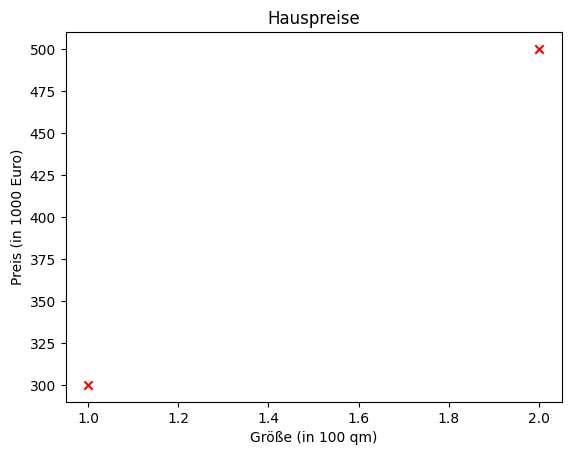

In [3]:
# Die Daten plotten:
plt.scatter(x, y, marker="x", c="r")

# marker="x" führt zu Kreuzen (Default: Punkte)
# c="r" führt zur Farbe Rot (Default: Blau)

# Titel setzen
plt.title("Hauspreise")

# x-Achsen-Label:
plt.xlabel("Größe (in 100 qm)")

# y-Achsen-Label:
plt.ylabel("Preis (in 1000 Euro)")

# Plot anzeigen:
plt.show()

## Werte des Modells berechnen

In [4]:
def compute_model_output(x, w, b):
# x: Array,   w,b: Skalare
# Gewünschte Ausgabe: Array mit Werten des Modells

    m = x.shape[0]   
    # Ist Länge des Arrays

    f_wb = np.zeros(m)
    # Array mit m Nullen

    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb

print(compute_model_output(x, 100, 150))

[250. 350.]


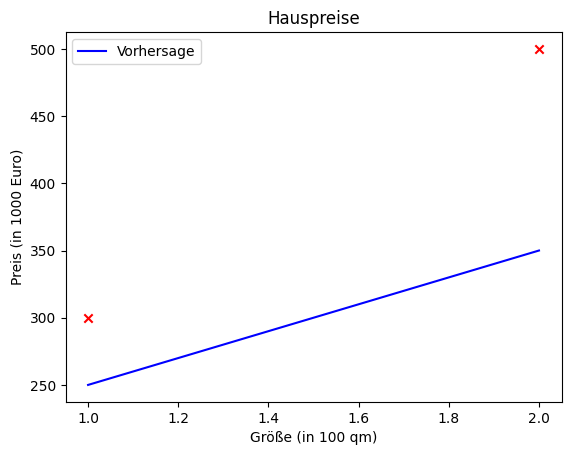

In [5]:
tmp_f_wb = compute_model_output(x, 100, 150)

# Modell-Vorhersage plotten:
plt.plot(x, tmp_f_wb, c="b", label="Vorhersage")

# Die Daten plotten:
plt.scatter(x, y, marker="x", c="r")

# Titel setzen
plt.title("Hauspreise")

# x-Achsen-Label:
plt.xlabel("Größe (in 100 qm)")

# y-Achsen-Label:
plt.ylabel("Preis (in 1000 Euro)")

# Label anzeigen:
plt.legend()

# Plot anzeigen:
plt.show()

## Wert der Kostenfunktion berechnen

In [6]:
def compute_cost(x, y, w, b):

    # Anzahl der Trainingsbeispiele
    m = x.shape[0]

    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    total_cost = (1 / (2 * m)) * cost_sum

    return total_cost

print(f"Kosten: {compute_cost(x, y, 100, 150)}")

Kosten: 6250.0


## Gradient berechnen

In [9]:
def compute_gradient(x, y, w, b):

    # Anzahl der Trainingsbeispiele
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

print(f"Gradient: {compute_gradient(x, y, 100, 150)}")

Gradient: (np.float64(-175.0), np.float64(-100.0))


## Gradientenverfahren

In [53]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):

    # xxx
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        # xxx
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # xxx
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # xxx
        J_history.append(cost_function(x, y, w, b))
        p_history.append([w,b])

        # xxx
        print(f"Iteration: { i }: Kosten {J_history[-1]}",
              f"dj_dw: {dj_dw}, dj_db: {dj_db}",
              f"w: {w}, b: {b}")
        
    return w, b, J_history, p_history

## Gradientenverfahren durchführen

In [58]:
# xxx
w_init = 0
b_init = 0
# xxx
iterations = 3000
alpha = 0.00000000001

w_final, b_final, J_hist, p_hist = gradient_descent(x, y, w_init, b_init, alpha, iterations, compute_cost, compute_gradient)

print(f"(w,b) nach Gradientenverfahren: ({w_final}, {b_final})")

Iteration: 0: Kosten 2.2562500000155376e+17 dj_dw: -50000000000150.0, dj_db: -25000150.0 w: 500.0000000015, b: 0.0002500015
Iteration: 1: Kosten 8.145062500063984e+19 dj_dw: 950000000003350.0, dj_db: 475000100.00175 w: -9000.000000032, b: -0.004499999500017499
Iteration: 2: Kosten 2.9403675625261923e+22 dj_dw: -1.805000000007315e+16, dj_db: -9025004650.0365 w: 171500.00000069948, b: 0.0857500470003475
Iteration: 3: Kosten 1.0614726900730728e+25 dj_dw: 3.4295000000157037e+17, dj_db: 171475085600.78525 w: -3258000.000015004, b: -1.629000809007505
Iteration: 4: Kosten 3.8319164111678256e+27 dj_dw: -6.516050000033266e+18, dj_db: -3258026629166.633 w: 61902500.00031765, b: 30.951265482658822
Iteration: 5: Kosten 1.3833218244330408e+30 dj_dw: 1.238049500006972e+20, dj_db: 61902505951448.6 w: -1176147000.0066543, b: -588.0737940318271
Iteration: 6: Kosten 4.9937917862085346e+32 dj_dw: -2.3522940500144845e+21, dj_db: -1176147613080892.2 w: 22346793500.13819, b: 11173.402336777095
Iteration: 7:

C:\Users\pbreu\AppData\Local\Temp\ipykernel_7400\134418313.py:9: RuntimeWarning: overflow encountered in scalar power
  cost = (f_wb - y[i]) ** 2
C:\Users\pbreu\AppData\Local\Temp\ipykernel_7400\1549048121.py:10: RuntimeWarning: overflow encountered in scalar multiply
  dj_dw_i = (f_wb - y[i]) * x[i]
C:\Users\pbreu\AppData\Local\Temp\ipykernel_7400\3216366755.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - alpha * dj_dw


## Zeichnen der Lernkurve

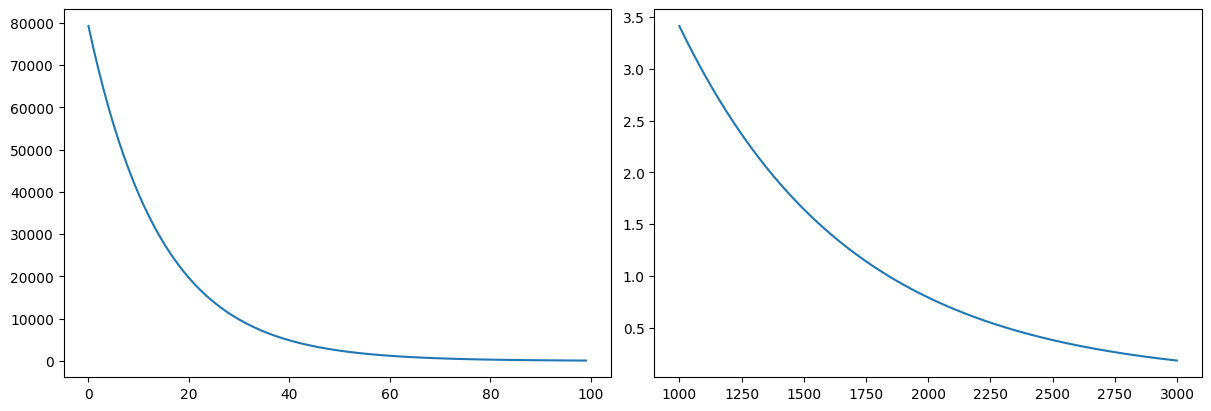

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])


## Vorhersage neuer Werte

In [37]:
print(f"100 qm Vorhersage: {w_final * 1.0 + b_final:0.1f} Tausend Euro")
print(f"120 qm Vorhersage: {w_final * 1.2 + b_final:0.1f} Tausend Euro")
print(f"200 qm Vorhersage: {w_final * 2.0 + b_final:0.1f} Tausend Euro")

100 qm Vorhersage: 300.7 Tausend Euro
120 qm Vorhersage: 340.5 Tausend Euro
200 qm Vorhersage: 499.5 Tausend Euro
